In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Replacing Blanks with 0 as tenure is 0 and no total charges are recorded

df['TotalCharges'] = df['TotalCharges'].replace(' ','0')
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [9]:
df['customerID'].duplicated().sum()

np.int64(0)

In [10]:
# Converted 0 and 1 value of Senior Citizen to yes/no to make it easter to understand

def conv(value):
    if value == 1:
        return 'yes'
    else:
        return 'no'

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

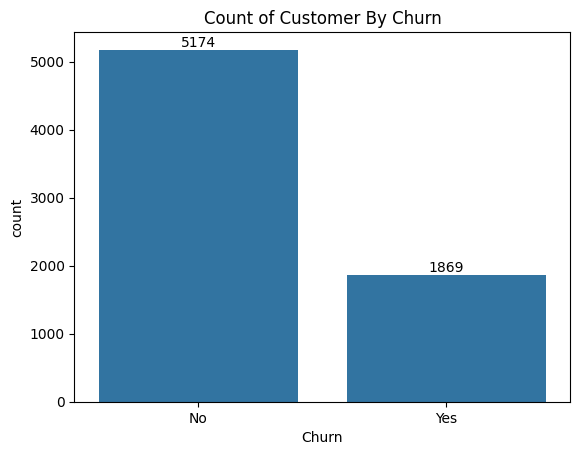

In [11]:
vk = sns.countplot(x = 'Churn',data =df)

vk.bar_label(vk.containers[0])
plt.title('Count of Customer By Churn')
plt.show()

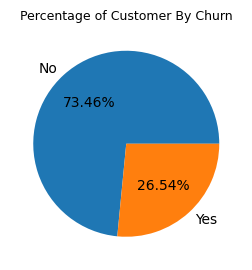

In [12]:
plt.figure(figsize=(3,5))
gb = df.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'], labels=gb.index, autopct = '%1.2f%%')
plt.title('Percentage of Customer By Churn',fontsize = 9)
plt.show()

*From the given pie chart we can conclude that 26.54% of our customers have Churned out*
*not let's explore the reason behind it*


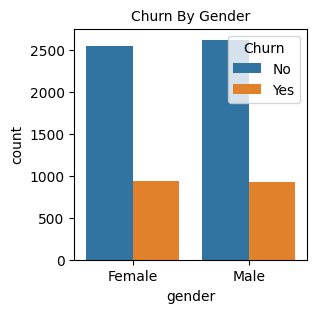

In [13]:
plt.figure(figsize = (3,3))
sns.countplot(x = 'gender',data = df, hue = 'Churn')
plt.title('Churn By Gender',fontsize=10)
plt.show()

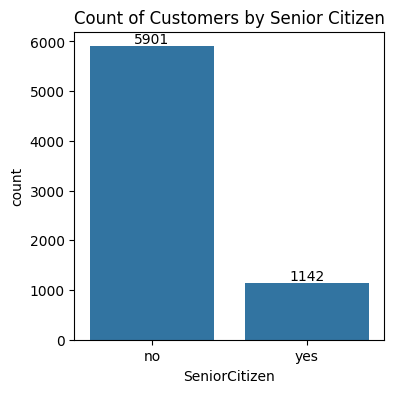

In [14]:
plt.figure(figsize=(4,4)) 
vk = sns.countplot(x='SeniorCitizen',data=df) 
vk.bar_label(vk.containers[0])
plt.title('Count of Customers by Senior Citizen') 
plt.show()

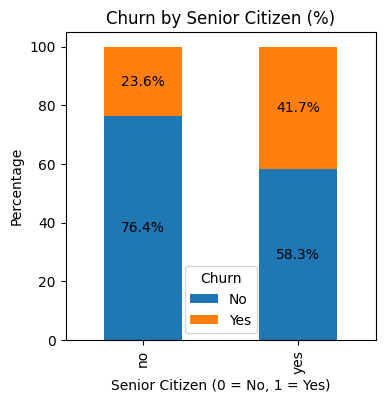

In [15]:
#Create count table
count_df = pd.crosstab(df['SeniorCitizen'], df['Churn'])

#Convert counts to percentages
percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100

#Plot stacked bar chart
ax = percent_df.plot(
    kind='bar',
    stacked=True,
    figsize=(4,4)
)

#Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

# Labels and title
plt.title('Churn by Senior Citizen (%)')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.legend(title='Churn')

*Comparative a greater percentage of people in senior citizen category have churned*

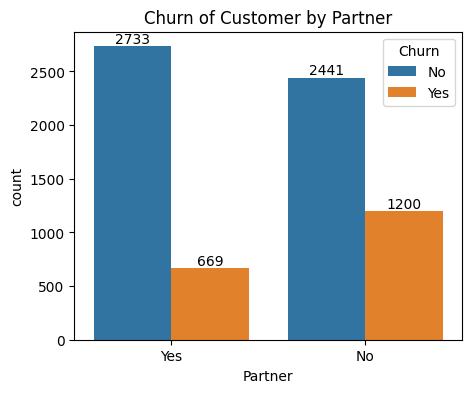

In [35]:
plt.figure(figsize=(5,4)) 
vk = sns.countplot(x='Partner',data=df,hue='Churn') 
vk.bar_label(vk.containers[0])
vk.bar_label(vk.containers[1])
plt.title('Churn of Customer by Partner') 
plt.show() 

*Customers without a partner have a higher churn count compared to those with a partner.*

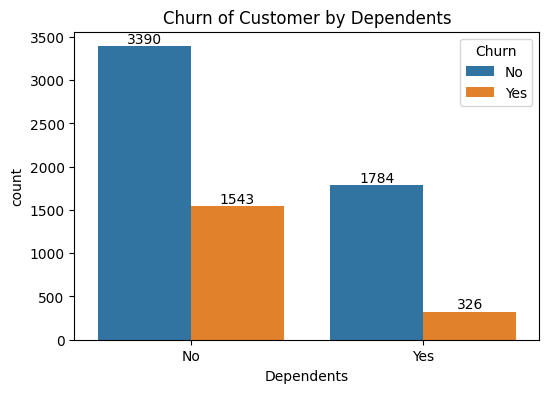

In [34]:
plt.figure(figsize=(6,4)) 
vk = sns.countplot(x='Dependents',data=df,hue='Churn') 
vk.bar_label(vk.containers[0])
vk.bar_label(vk.containers[1])
plt.title('Churn of Customer by Dependents') 

plt.show()

*This suggests that customers with dependents are more likely to stay and have a lower churn rate.*

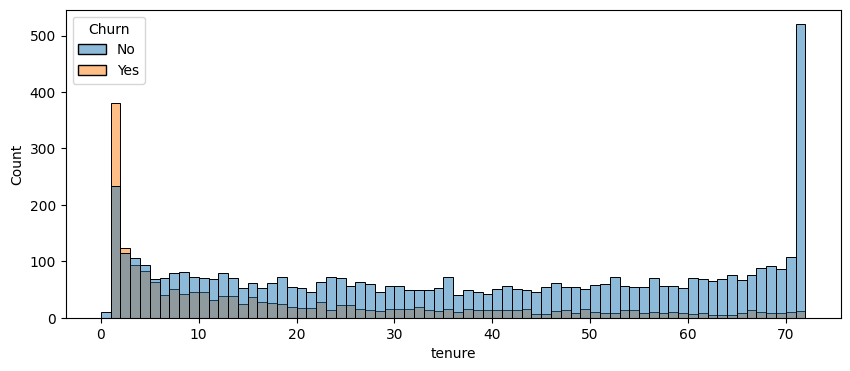

In [16]:
plt.figure(figsize=(10,4))
sns.histplot(x = 'tenure', data = df, bins = 72, hue = 'Churn')
plt.show()

*People who are used our services for a long time have time have stayed and people who have used our services 1 or 2 months have churned*

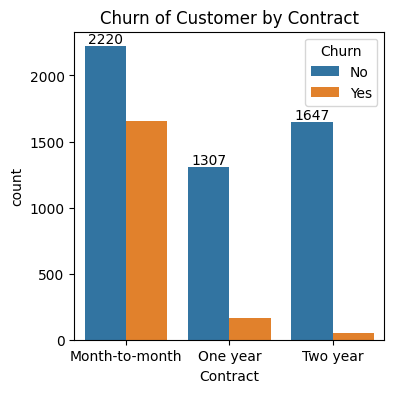

In [17]:
plt.figure(figsize=(4,4)) 
vk = sns.countplot(x='Contract',data=df,hue='Churn') 
vk.bar_label(vk.containers[0])
plt.title('Churn of Customer by Contract') 
plt.show()

*People who have month to month contract are likely to churn then from those who have 1 or 2 year of contract*

In [18]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

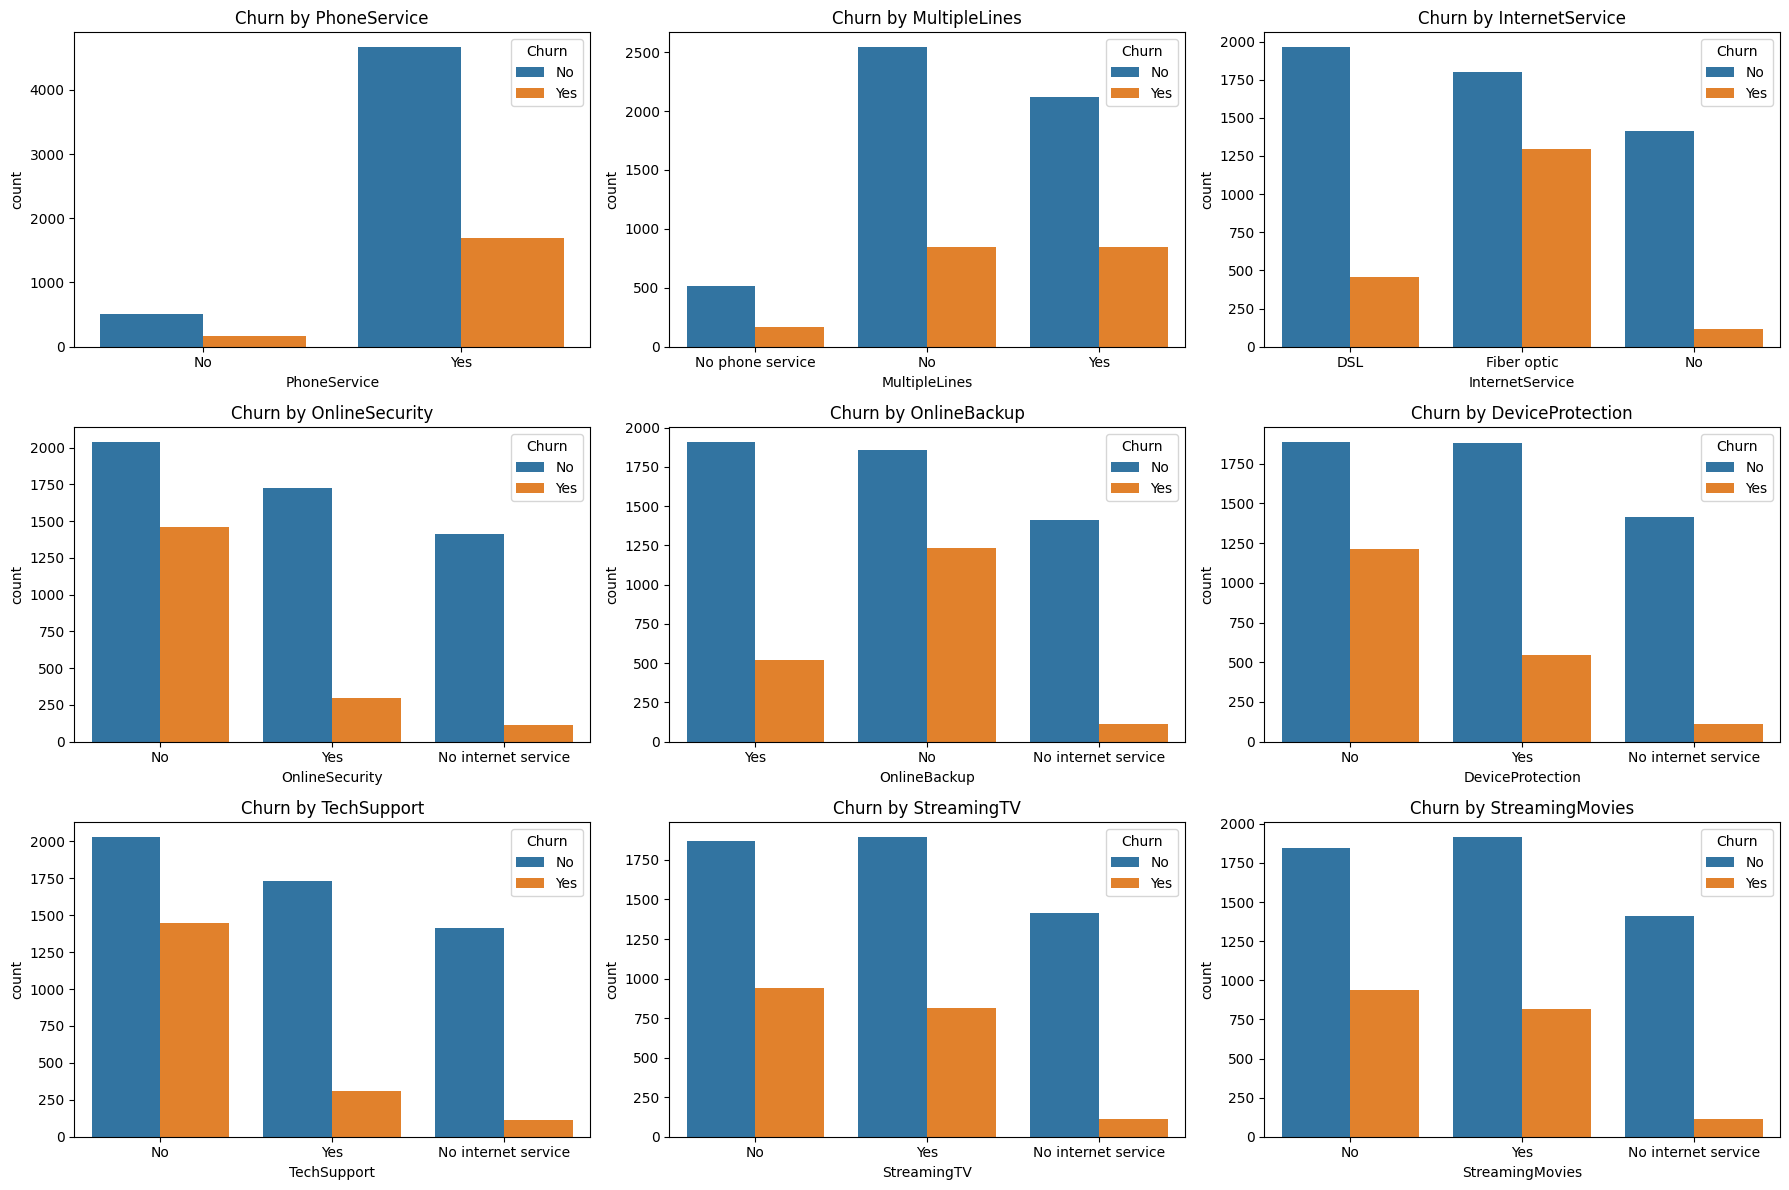

In [ ]:
# list of columns
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# create subplot grid (3 rows, 3 columns)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()   # convert into 1D array for easy loop

# loop through each column
for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, hue='Churn', ax=axes[i])
    axes[i].set_title(f'Churn by {col}')

# adjust layout
plt.tight_layout()
plt.show()


*Customers with PhoneService and MultipleLines show higher churn compared to those without these services.*

*Churn is significantly higher among users with Fiber optic internet, while DSL users have lower churn.*

*Lack of OnlineSecurity, TechSupport, and DeviceProtection is strongly associated with increased churn.*

*Customers without additional services like StreamingTV, StreamingMovies, and OnlineBackup also tend to churn more frequently.*

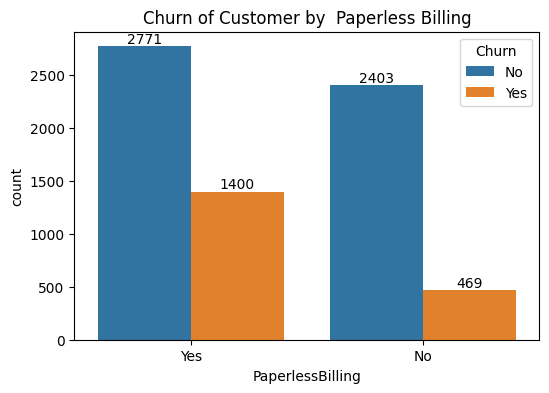

In [37]:
plt.figure(figsize=(6,4)) 
vk = sns.countplot(x='PaperlessBilling',data=df,hue='Churn') 
vk.bar_label(vk.containers[0])
vk.bar_label(vk.containers[1])
plt.title('Churn of Customer by  Paperless Billing') 
plt.show()

*Customers using paperless billing have a significantly higher churn rate compared to those who do not use paperless billing.*

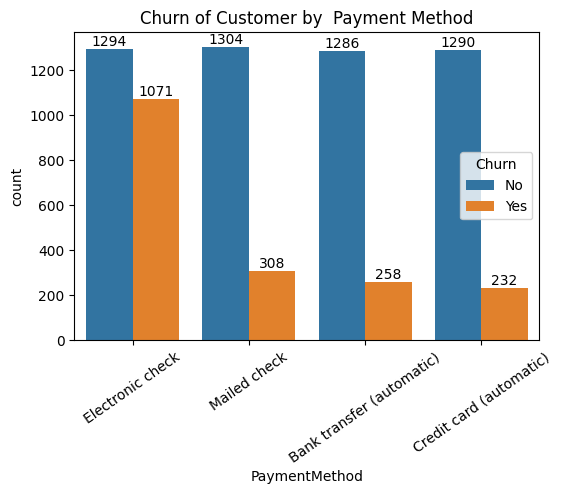

In [28]:
plt.figure(figsize=(6,4)) 
vk = sns.countplot(x='PaymentMethod',data=df,hue='Churn') 
vk.bar_label(vk.containers[0])
vk.bar_label(vk.containers[1])
plt.title('Churn of Customer by  Payment Method') 
plt.xticks(rotation = 35)
plt.show()

*Customer is likely to Churn when he is using Electronic Check as a payment method.*